In [1]:
import os
dataset_path = "/kaggle/input/datasets/janiherbert/cherry-segmentation-dataset/Cherry Segmentation"
image_dir = dataset_path + "/Original Images"
mask_dir = dataset_path + "/Mask"

0 255
(3000, 3000, 3)
(3000, 3000)
torch.Size([256, 256, 3])
torch.Size([256, 256])
torch.Size([3, 256, 256])


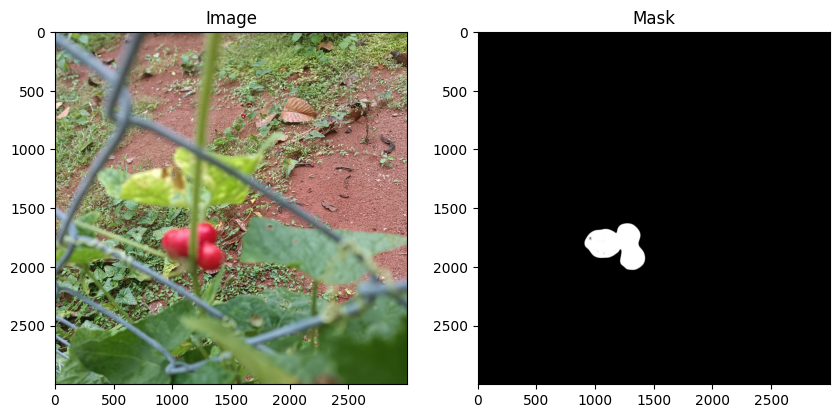

In [2]:
#Visualise One Image And Mask

import cv2
import matplotlib.pyplot as plt

images = sorted(os.listdir(image_dir))
masks = sorted(os.listdir(mask_dir))

img_path = os.path.join(
    image_dir,
    images[0]
)

mask_path = os.path.join(
    mask_dir,
    masks[0]
)
image = cv2.imread(img_path)
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path,0)

plt.figure(figsize = (10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask,cmap = "gray")
plt.title("Mask")

#Checking Min And Max Of Mask
print(mask.min(),mask.max())

#Normalise
mask = mask/255.0
image = image/255.0

#Check Size Of Image And Mask

print(image.shape)
print(mask.shape)

#Resize
image = cv2.resize(image,(256,256))
mask = cv2.resize(mask,(256,256))

#Convert To pyTorch

import torch

image = torch.tensor(image).float()
mask = torch.tensor(mask).float()

print(image.shape)
print(mask.shape)

#Rearrange Image Dimensions

image = image.permute(2,0,1)
print(image.shape)

#No need to permute mask since only 2 dimensions

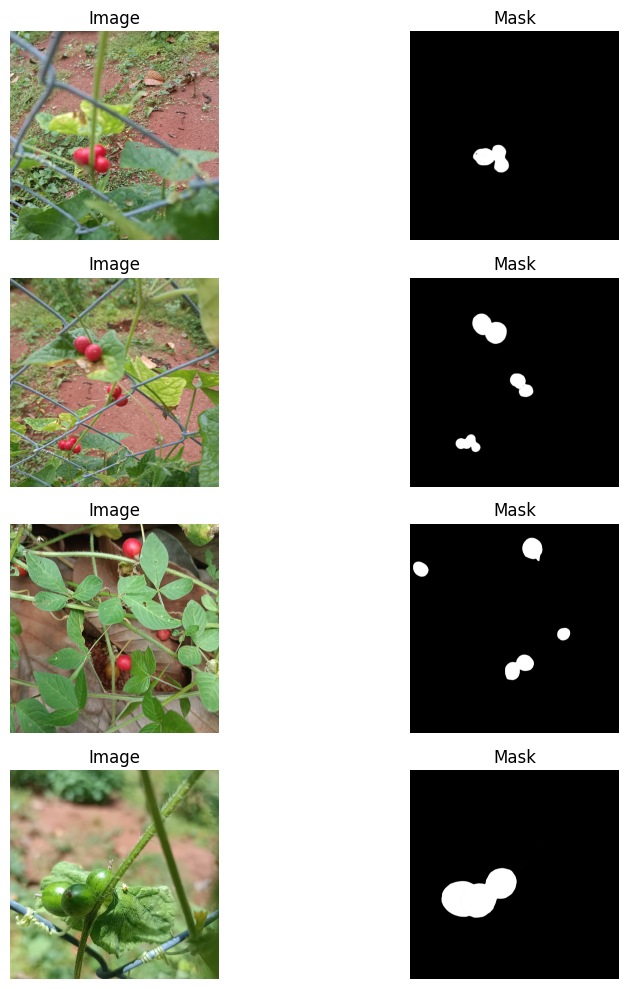

In [3]:
#Visualising Dataset Description

import matplotlib.pyplot as plt

plt.figure(figsize = (10,10))
images = sorted(os.listdir(image_dir))
masks = sorted(os.listdir(mask_dir))
for i in range(4):
    img_path = os.path.join(image_dir,images[i])
    mask_path = os.path.join(mask_dir,masks[i])

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path,0)

    #Plotting Image
    plt.subplot(4,2,i*2 + 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("Off")

    #Plotting Mask
    plt.subplot(4,2,i*2 + 2)
    plt.imshow(mask,cmap = "gray")
    plt.title("Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [4]:
#Augmentation Pipeline
import albumentations as A

transform = A.Compose([
    A.HorizontalFlip(p = 0.5),
    A.VerticalFlip(p = 0.5),
    A.Rotate(limit = 30, p = 0.5)
])

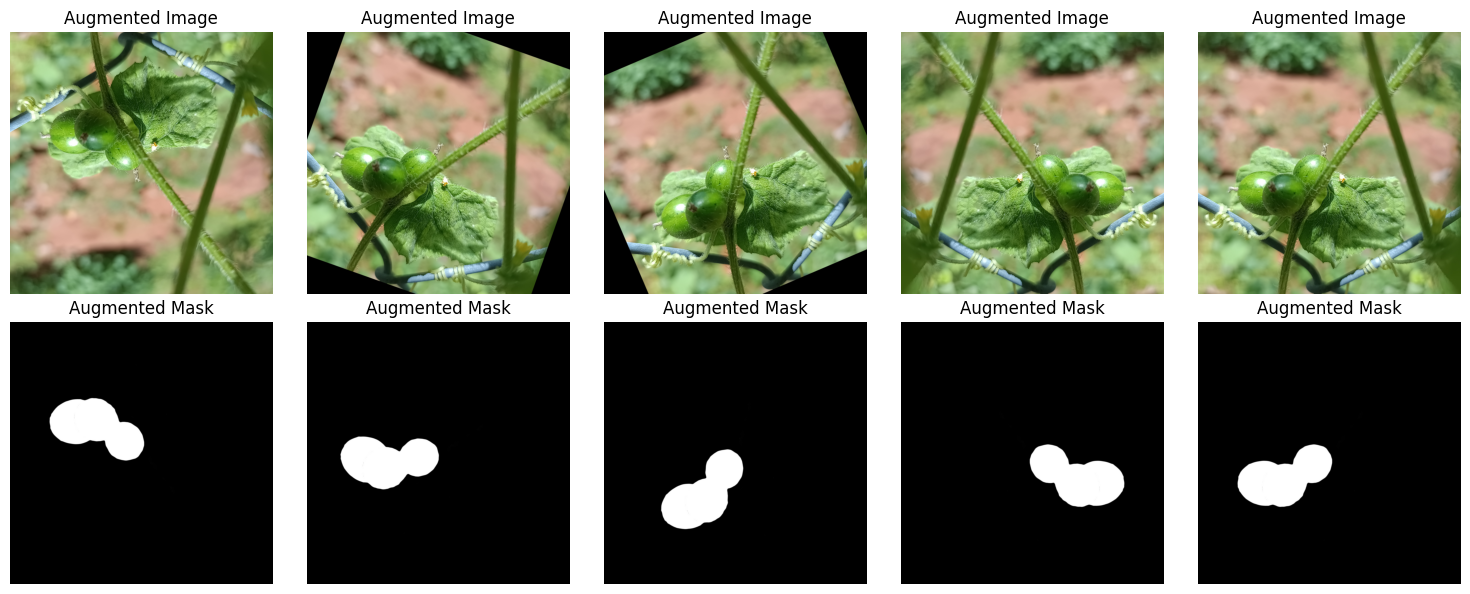

In [5]:
# Augmentation VIsualisation
import matplotlib.pyplot as plt
import cv2
import os

# Read one sample
images = sorted(os.listdir(image_dir))
masks = sorted(os.listdir(mask_dir))

img_path = os.path.join(image_dir,images[i])
mask_path = os.path.join(mask_dir,masks[i])

image = cv2.imread(img_path)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

mask = cv2.imread(mask_path,0)

# Create Figure
fig, axes = plt.subplots(
    2,
    5,
    figsize=(15,6)
)

for i in range(5):

    # Apply augmentation
    augmented = transform(
        image=image,
        mask=mask
    )

    aug_image = augmented["image"]

    aug_mask = augmented["mask"]

    # Show augmented image
    axes[0,i].imshow(aug_image)

    axes[0,i].set_title(
        "Augmented Image"
    )

    axes[0,i].axis("off")

    # Show augmented mask
    axes[1,i].imshow(
        aug_mask,
        cmap='gray'
    )

    axes[1,i].set_title(
        "Augmented Mask"
    )

    axes[1,i].axis("off")

plt.tight_layout()

plt.show()

In [6]:
from torch.utils.data import Dataset
import cv2
import torch


class SegDataSet(Dataset):
    def __init__(self,image_dir,mask_dir,transform = None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.transform = transform
        
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))
                            
    def __len__(self):
        return len(self.images)
        
    def __getitem__(self,idx):
        img_path = os.path.join(
            self.image_dir,
            self.images[idx]
        )
        mask_path = os.path.join(
            self.mask_dir,
            self.masks[idx]
        )
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path,0)

        #Augmentation
        if self.transform:
            augmented = self.transform(
                image = image,
                mask = mask
            )
            image = augmented["image"]
            mask = augmented["mask"]
        
        #Resize
        image = cv2.resize(image,(256,256))
        mask = cv2.resize(mask,(256,256))

        #normalise
        image = image/255.0
        mask = mask/255.0

        #Convert To Tensor
        image = torch.tensor(image).float()
        mask = torch.tensor(mask).float()
        
        image = image.permute(2,0,1)
        return image,mask
        


In [7]:
#TEST
dataset = SegDataSet(image_dir,mask_dir, transform = transform)
image,mask = dataset[0]
print(image.shape)

torch.Size([3, 256, 256])


In [8]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size = 4,
    shuffle = True
)

#for im , ma in loader:
#    print(im)
#   print(ma)
#   break

In [9]:
import torch.nn as nn


In [10]:
#U-Net
import torch.nn as nn

class DoubleConv(nn.Module):
    
    def __init__(self,in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding = 1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),

        nn.Conv2d(out_channels,out_channels, 3, padding = 1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)

#Encoder
class Down(nn.Module):
    def __init__(self,in_channels, out_channels):
        super().__init__()
        self.down = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    def forward(self,x):
        return self.down(x)


#Decoder
class Up(nn.Module):
    def __init__(self,in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size = 2,
            stride = 2
        )
        self.conv = DoubleConv(
            in_channels,
            out_channels
        )

    def forward(self,x1,x2):
        x1 = self.up(x1)
        x = torch.cat([x2,x1],dim = 1)
        return self.conv(x)

#Unet
class UNET(nn.Module):
    def __init__(self):
        super().__init__()
        self.inc = DoubleConv(3,64)
        self.down1 = Down(64,128)
        self.down2 = Down(128,256)
        self.down3 = Down(256,512)
        self.up1 = Up(512,256)
        self.up2 = Up(256,128)
        self.up3 = Up(128,64)
        
        self.outc = nn.Conv2d(64,1,kernel_size = 1)

    def forward(self,x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x = self.up1(x4,x3)
        x = self.up2(x,x2)
        x = self.up3(x,x1)
        x = self.outc(x)
        return x





In [11]:
#Creating model and connceting to GPU
device = torch.device("cuda")
model = UNET().to(device)

In [12]:
#Loss Function For Single
#criterion = nn.BCEWithLogitsLoss()

#Combined Loss Function
import torch.nn.functional as F

def dice_loss(preds, masks, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = preds.view(-1)
    masks = masks.view(-1)
    intersection = (preds * masks).sum()
    return 1 - (2. * intersection + smooth) / (preds.sum() + masks.sum() + smooth)

def combined_loss(outputs, masks):
    bce = F.binary_cross_entropy_with_logits(outputs, masks)
    dl  = dice_loss(outputs, masks)
    return bce + dl


In [13]:
#Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.0001
)

In [14]:
#Dont use this
#Training Loop
#epochs = 5
#for epoch in range(epochs):
#    epoch_loss = 0
#    for images, masks in loader:
#        images = images.to(device)
#        masks = masks.unsqueeze(1).to(device)
#        outputs = model(images)
  #      loss = combined_loss(outputs,masks)
#        optimizer.zero_grad()
#        loss.backward()
#        optimizer.step()
##        epoch_loss += loss.item()

 #   avg_loss = epoch_loss / len(loader)
#    print(f"Epoch : {epoch+1} - Loss : {avg_loss}")

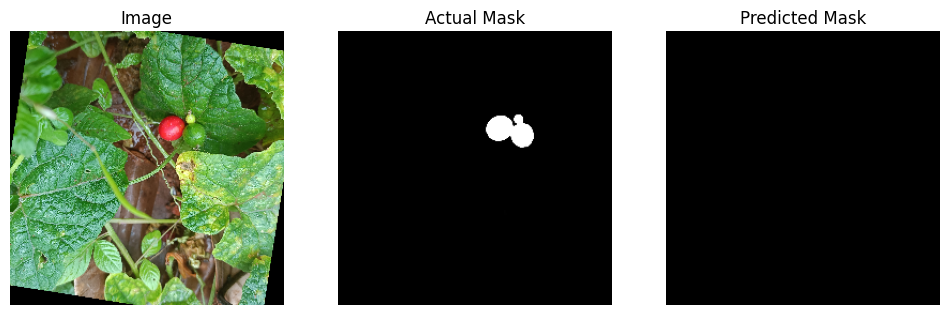

In [15]:
#Prediction Visualisation

import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    images, masks  = next(iter(loader))
    images = images.to(device)
    outputs = model(images)
    preds = torch.sigmoid(outputs)
    preds = (preds > 0.5).float()

images = images.cpu()
masks = masks.cpu()
preds = preds.cpu()

image = images[0]
mask = masks[0]
pred = preds[0]

image = image.permute(1,2,0)
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask,cmap="gray")
plt.title("Actual Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred.squeeze(0),cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

In [16]:
#DICE Score

def dice_score(preds, masks):
    smooth = 1e-6
    preds = preds.view(-1)
    masks = masks.view(-1)
    intersection = (preds * masks).sum()
    dice = (2 * intersection + smooth) / (preds.sum() + masks.sum() + smooth)
    
    
    return dice.item()

In [17]:
#IOU Score
def iou_score(preds, masks):

    smooth = 1e-6
    preds = preds.view(-1)
    masks = masks.view(-1)

    intersection = (
        preds * masks
    ).sum()

    union = (
        preds.sum()
        +
        masks.sum()
        -
        intersection
    )

    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return iou.item()

In [18]:
#Test Train Split

from torch.utils.data import random_split

train_size = int(
    0.8 * len(dataset)
)
val_size = (
    len(dataset) - train_size
)
train_dataset,val_dataset = random_split(
    dataset,
    [train_size,val_size]
)

#Loaders For This
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

In [19]:
#Loss Arrays
train_losses = []
val_losses = []

#DICE Score And IOU Arrays
dice_scores = []
iou_scores = []

#Best Model
best_dice = 0.0

epochs = 60
for epoch in range(epochs):
    #Training Loop
    epoch_loss = 0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.unsqueeze(1).to(device)
        outputs = model(images)
        loss = combined_loss(outputs,masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch : {epoch+1} -  Training Loss : {avg_loss}")
    train_losses.append(avg_loss)

    #Validation Loop
    model.eval()
    val_loss = 0
    dice = 0
    iou = 0
    with torch.no_grad():
        for images,masks in val_loader:  
            images = images.to(device)
            masks = masks.unsqueeze(1).to(device)
            outputs = model(images)
            #Loss 
            loss = combined_loss(outputs,masks)
            val_loss += loss.item()

            #DICE AND IOU
            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).float()
            dice += dice_score(preds,masks)
            iou += iou_score(preds,masks)
    avg_val_loss = ( val_loss / len(val_loader) )
    val_losses.append(avg_val_loss)
    avg_dice = dice / len(val_loader)
    avg_iou = iou / len(val_loader)
    dice_scores.append(avg_dice)
    iou_scores.append(avg_iou)

    #Saving Best Model
    if(avg_dice > best_dice):
        best_dice = avg_dice
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Model saved! Best Dice: {best_dice:.4f}")
    model.train()    
    
    print(f"Epoch : {epoch+1} -  Val Loss : {avg_val_loss}")
    print(f"Epoch : {epoch+1} -  Dice Score : {avg_dice}")
    print(f"Epoch : {epoch+1} -  IOU Score : {avg_iou}")
    print("\n")
    
print(train_losses)
print(val_losses)

Epoch : 1 -  Training Loss : 1.4205777674913407
Model saved! Best Dice: 0.0000
Epoch : 1 -  Val Loss : 1.1291553616523742
Epoch : 1 -  Dice Score : 1.4379061968883277e-10
Epoch : 1 -  IOU Score : 1.4379061968883277e-10


Epoch : 2 -  Training Loss : 1.4695641279220581
Model saved! Best Dice: 0.5963
Epoch : 2 -  Val Loss : 1.3644163608551025
Epoch : 2 -  Dice Score : 0.5962705582380294
Epoch : 2 -  IOU Score : 0.4351945221424103


Epoch : 3 -  Training Loss : 1.198218423128128
Model saved! Best Dice: 0.7251
Epoch : 3 -  Val Loss : 1.2116738080978393
Epoch : 3 -  Dice Score : 0.7250927716493607
Epoch : 3 -  IOU Score : 0.5843271300196647


Epoch : 4 -  Training Loss : 1.0879427284002303
Model saved! Best Dice: 0.7849
Epoch : 4 -  Val Loss : 1.0792716324329377
Epoch : 4 -  Dice Score : 0.7848660409450531
Epoch : 4 -  IOU Score : 0.6637625828385353


Epoch : 5 -  Training Loss : 1.0389685764908791
Epoch : 5 -  Val Loss : 1.0625288963317872
Epoch : 5 -  Dice Score : 0.7458728045225144
Epoch

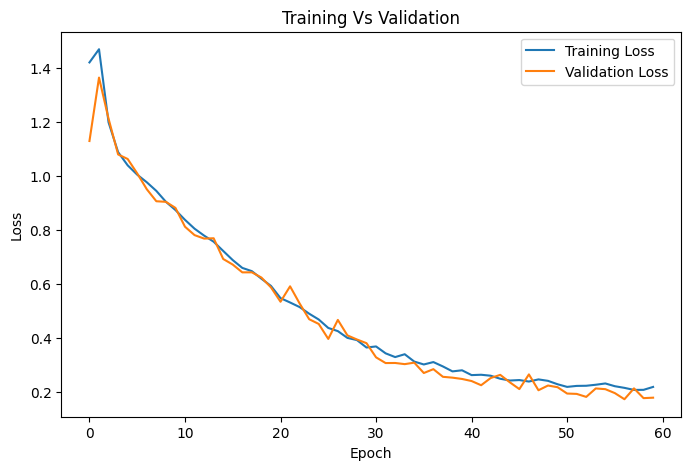

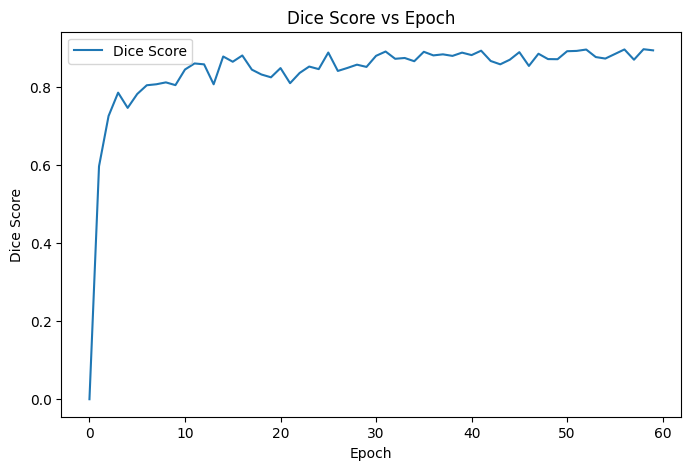

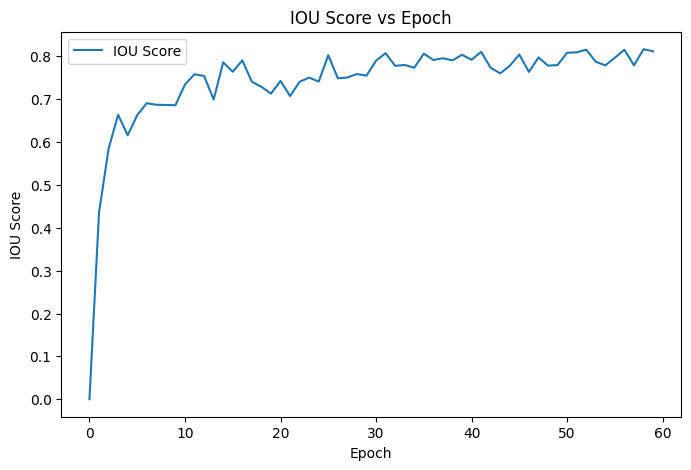

In [20]:
#Plotting The Curves

import matplotlib.pyplot as plt

plt.figure(figsize = (8,5))
plt.plot(train_losses,label = "Training Loss")
plt.plot(val_losses,label = "Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")
plt.title("Training Vs Validation")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(dice_scores, label="Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice Score vs Epoch")
plt.legend()
plt.show()

plt.figure(figsize = (8,5))
plt.plot(iou_scores,label = "IOU Score")
plt.xlabel("Epoch")
plt.ylabel("IOU Score")
plt.title("IOU Score vs Epoch")
plt.legend()
plt.show()

In [21]:
#Attention UNET

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int): #F_g -> decoder, F_l -> encoder from skip connection
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU()

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNET(nn.Module):
    def __init__(self):
        super().__init__()
        self.inc   = DoubleConv(3, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        
        self.ag1 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.ag2 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.ag3 = AttentionGate(F_g=64,  F_l=64,  F_int=32)
        
        self.up1 = Up(512, 256)
        self.up2 = Up(256, 128)
        self.up3 = Up(128, 64)
        self.outc = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        
        x3 = self.ag1(g=self.up1.up(x4), x=x3)
        x  = self.up1(x4, x3)
        
        x2 = self.ag2(g=self.up2.up(x),  x=x2)
        x  = self.up2(x, x2)
        
        x1 = self.ag3(g=self.up3.up(x),  x=x1)
        x  = self.up3(x, x1)
        
        return self.outc(x)

In [22]:
#Model for Attention UNET And Optimizer

model2 = AttentionUNET().to(device)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.0001)

In [23]:
train_losses2 = []
val_losses2 = []
dice_scores2 = []
iou_scores2 = []
best_dice2 = 0.0
epochs = 60

for epoch in range(epochs):
    model2.train()
    epoch_loss = 0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.unsqueeze(1).to(device)
        outputs = model2(images)
        loss = combined_loss(outputs, masks)
        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch : {epoch+1} - Training Loss : {avg_loss}")
    train_losses2.append(avg_loss)

    model2.eval()
    val_loss = 0
    dice = 0
    iou = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.unsqueeze(1).to(device)
            outputs = model2(images)
            loss = combined_loss(outputs, masks)
            val_loss += loss.item()
            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).float()
            dice += dice_score(preds, masks)
            iou += iou_score(preds, masks)

    avg_val_loss = val_loss / len(val_loader)
    avg_dice = dice / len(val_loader)
    avg_iou = iou / len(val_loader)
    val_losses2.append(avg_val_loss)
    dice_scores2.append(avg_dice)
    iou_scores2.append(avg_iou)

    if avg_dice > best_dice2:
        best_dice2 = avg_dice
        torch.save(model2.state_dict(), "attention_unet.pth")
        print(f"Model saved! Best Dice: {best_dice2:.4f}")

    print(f"Epoch : {epoch+1} - Val Loss : {avg_val_loss}")
    print(f"Epoch : {epoch+1} - Dice Score : {avg_dice}")
    print(f"Epoch : {epoch+1} - IOU Score : {avg_iou}")
    print("\n")

Epoch : 1 - Training Loss : 1.3032234847545623
Model saved! Best Dice: 0.7788
Epoch : 1 - Val Loss : 1.2662826299667358
Epoch : 1 - Dice Score : 0.7788283824920654
Epoch : 1 - IOU Score : 0.644851678609848


Epoch : 2 - Training Loss : 1.1444168984889984
Epoch : 2 - Val Loss : 1.1514734983444215
Epoch : 2 - Dice Score : 0.7494057506322861
Epoch : 2 - IOU Score : 0.6188294902443886


Epoch : 3 - Training Loss : 1.0963711902499198
Epoch : 3 - Val Loss : 1.0913820564746857
Epoch : 3 - Dice Score : 0.7760868430137634
Epoch : 3 - IOU Score : 0.6544722706079483


Epoch : 4 - Training Loss : 1.0561610475182532
Model saved! Best Dice: 0.8113
Epoch : 4 - Val Loss : 1.0379593133926392
Epoch : 4 - Dice Score : 0.8112591326236724
Epoch : 4 - IOU Score : 0.6863231480121612


Epoch : 5 - Training Loss : 1.0266772761940957
Model saved! Best Dice: 0.8319
Epoch : 5 - Val Loss : 1.00531707406044
Epoch : 5 - Dice Score : 0.831887286901474
Epoch : 5 - IOU Score : 0.7160549581050872


Epoch : 6 - Training 

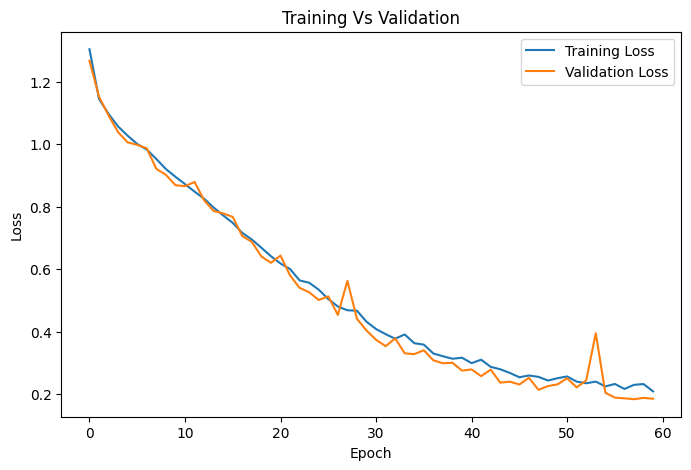

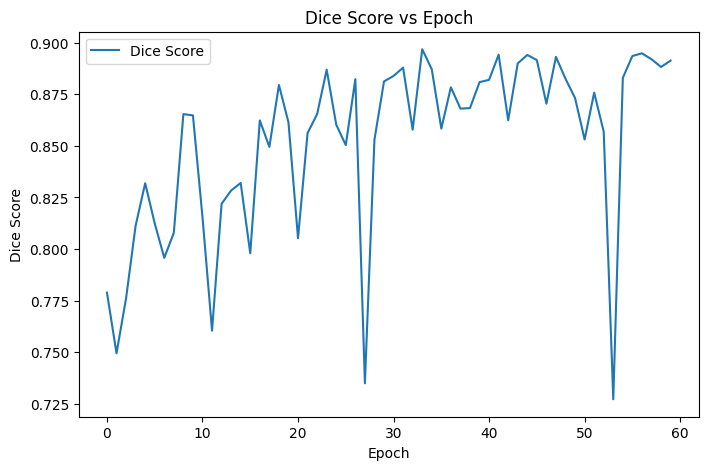

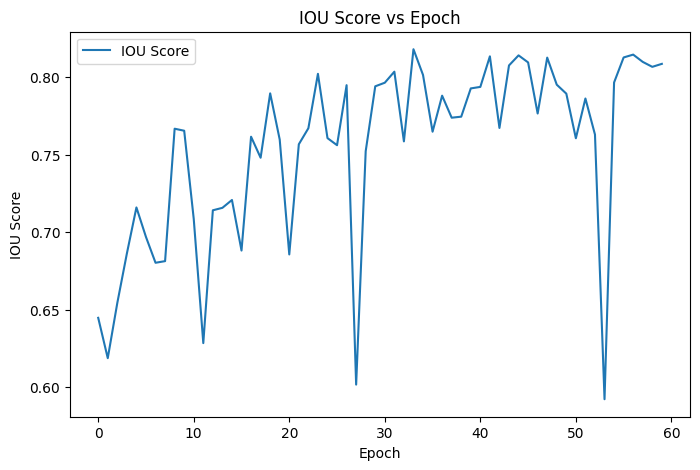

In [24]:
#Plotting The Curves

import matplotlib.pyplot as plt

plt.figure(figsize = (8,5))
plt.plot(train_losses2,label = "Training Loss")
plt.plot(val_losses2,label = "Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")
plt.title("Training Vs Validation")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(dice_scores2, label="Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice Score vs Epoch")
plt.legend()
plt.show()

plt.figure(figsize = (8,5))
plt.plot(iou_scores2,label = "IOU Score")
plt.xlabel("Epoch")
plt.ylabel("IOU Score")
plt.title("IOU Score vs Epoch")
plt.legend()
plt.show()

In [25]:
#Residual UNET

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels)
        )
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1),
            nn.BatchNorm2d(out_channels)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv(x) + self.shortcut(x))

class ResidualDown(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.down = nn.Sequential(
            nn.MaxPool2d(2),
            ResidualBlock(in_channels, out_channels)
        )
    def forward(self, x):
        return self.down(x)

class ResidualUp(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = ResidualBlock(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class ResidualUNET(nn.Module):
    def __init__(self):
        super().__init__()
        self.inc   = ResidualBlock(3, 64)
        self.down1 = ResidualDown(64, 128)
        self.down2 = ResidualDown(128, 256)
        self.down3 = ResidualDown(256, 512)
        self.up1   = ResidualUp(512, 256)
        self.up2   = ResidualUp(256, 128)
        self.up3   = ResidualUp(128, 64)
        self.outc  = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x  = self.up1(x4, x3)
        x  = self.up2(x, x2)
        x  = self.up3(x, x1)
        return self.outc(x)

In [26]:
#Model Creation

model3 = ResidualUNET().to(device)
optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.0001)

In [27]:
train_losses3 = []
val_losses3 = []
dice_scores3 = []
iou_scores3 = []
best_dice3 = 0.0
epochs = 60

for epoch in range(epochs):
    model3.train()
    epoch_loss = 0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.unsqueeze(1).to(device)
        outputs = model3(images)
        loss = combined_loss(outputs, masks)
        optimizer3.zero_grad()
        loss.backward()
        optimizer3.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch : {epoch+1} - Training Loss : {avg_loss}")
    train_losses3.append(avg_loss)

    model3.eval()
    val_loss = 0
    dice = 0
    iou = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.unsqueeze(1).to(device)
            outputs = model3(images)
            loss = combined_loss(outputs, masks)
            val_loss += loss.item()
            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).float()
            dice += dice_score(preds, masks)
            iou += iou_score(preds, masks)

    avg_val_loss = val_loss / len(val_loader)
    avg_dice = dice / len(val_loader)
    avg_iou = iou / len(val_loader)
    val_losses3.append(avg_val_loss)
    dice_scores3.append(avg_dice)
    iou_scores3.append(avg_iou)

    if avg_dice > best_dice3:
        best_dice3 = avg_dice
        torch.save(model3.state_dict(), "residual_unet.pth")
        print(f"Model saved! Best Dice: {best_dice3:.4f}")

    print(f"Epoch : {epoch+1} - Val Loss : {avg_val_loss}")
    print(f"Epoch : {epoch+1} - Dice Score : {avg_dice}")
    print(f"Epoch : {epoch+1} - IOU Score : {avg_iou}")
    print("\n")

Epoch : 1 - Training Loss : 1.2756118476390839
Model saved! Best Dice: 0.7302
Epoch : 1 - Val Loss : 1.1948781967163087
Epoch : 1 - Dice Score : 0.730240648984909
Epoch : 1 - IOU Score : 0.5877730220556259


Epoch : 2 - Training Loss : 1.0257398515939713
Model saved! Best Dice: 0.8170
Epoch : 2 - Val Loss : 0.9917007327079773
Epoch : 2 - Dice Score : 0.8169684916734695
Epoch : 2 - IOU Score : 0.705564272403717


Epoch : 3 - Training Loss : 0.9394958794116974
Epoch : 3 - Val Loss : 0.9470921099185944
Epoch : 3 - Dice Score : 0.7738564282655715
Epoch : 3 - IOU Score : 0.6539106339216232


Epoch : 4 - Training Loss : 0.8733037799596787
Epoch : 4 - Val Loss : 0.8533183574676514
Epoch : 4 - Dice Score : 0.8035140693187713
Epoch : 4 - IOU Score : 0.6904967099428176


Epoch : 5 - Training Loss : 0.8030811905860901
Model saved! Best Dice: 0.8485
Epoch : 5 - Val Loss : 0.764676982164383
Epoch : 5 - Dice Score : 0.8485317885875702
Epoch : 5 - IOU Score : 0.7409508466720581


Epoch : 6 - Training

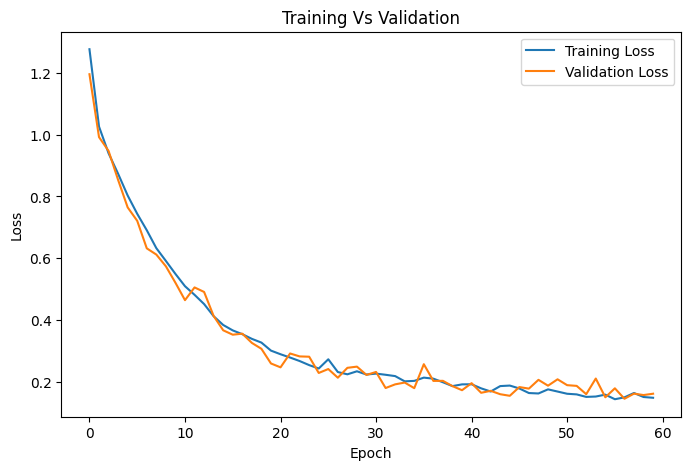

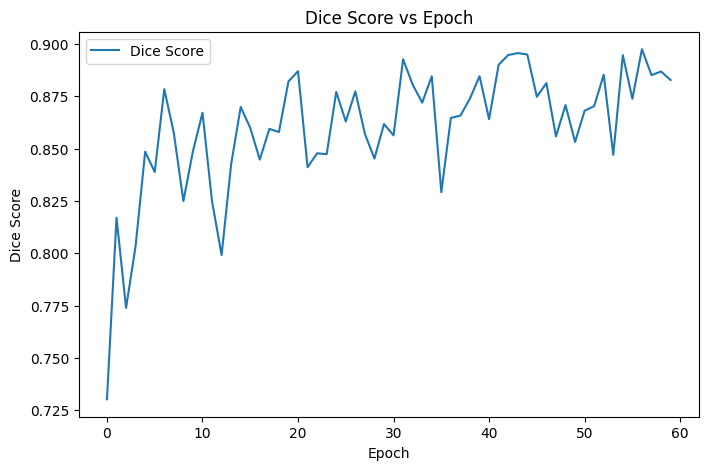

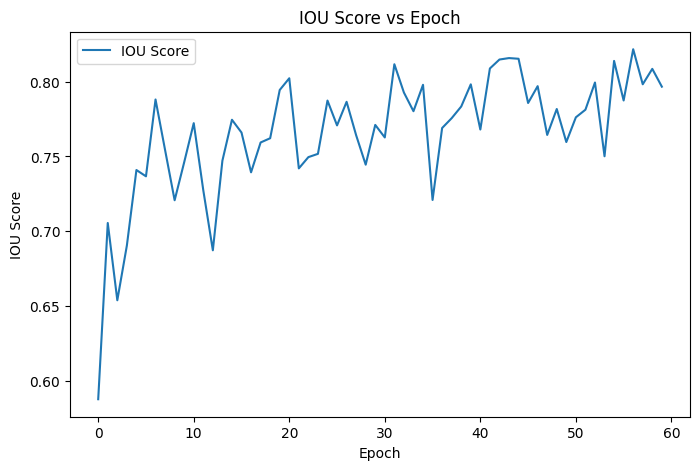

In [28]:
#Plotting The Curves

import matplotlib.pyplot as plt

plt.figure(figsize = (8,5))
plt.plot(train_losses3,label = "Training Loss")
plt.plot(val_losses3,label = "Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")
plt.title("Training Vs Validation")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(dice_scores3, label="Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice Score vs Epoch")
plt.legend()
plt.show()

plt.figure(figsize = (8,5))
plt.plot(iou_scores3,label = "IOU Score")
plt.xlabel("Epoch")
plt.ylabel("IOU Score")
plt.title("IOU Score vs Epoch")
plt.legend()
plt.show()

In [29]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:00


In [30]:
#ResNet34

import segmentation_models_pytorch as smp

model4 = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

optimizer4 = torch.optim.Adam(model4.parameters(), lr=0.0001)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [31]:
train_losses4 = []
val_losses4 = []
dice_scores4 = []
iou_scores4 = []
best_dice4 = 0.0
epochs = 60

for epoch in range(epochs):
    model4.train()
    epoch_loss = 0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.unsqueeze(1).to(device)
        outputs = model4(images)
        loss = combined_loss(outputs, masks)
        optimizer4.zero_grad()
        loss.backward()
        optimizer4.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch : {epoch+1} - Training Loss : {avg_loss}")
    train_losses4.append(avg_loss)

    model4.eval()
    val_loss = 0
    dice = 0
    iou = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.unsqueeze(1).to(device)
            outputs = model4(images)
            loss = combined_loss(outputs, masks)
            val_loss += loss.item()
            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).float()
            dice += dice_score(preds, masks)
            iou += iou_score(preds, masks)

    avg_val_loss = val_loss / len(val_loader)
    avg_dice = dice / len(val_loader)
    avg_iou = iou / len(val_loader)
    val_losses4.append(avg_val_loss)
    dice_scores4.append(avg_dice)
    iou_scores4.append(avg_iou)

    if avg_dice > best_dice4:
        best_dice4 = avg_dice
        torch.save(model4.state_dict(), "resnet_unet.pth")
        print(f"Model saved! Best Dice: {best_dice4:.4f}")

    print(f"Epoch : {epoch+1} - Val Loss : {avg_val_loss}")
    print(f"Epoch : {epoch+1} - Dice Score : {avg_dice}")
    print(f"Epoch : {epoch+1} - IOU Score : {avg_iou}")
    print("\n")

Epoch : 1 - Training Loss : 1.1345774322748183
Model saved! Best Dice: 0.4744
Epoch : 1 - Val Loss : 1.080785870552063
Epoch : 1 - Dice Score : 0.4743522047996521
Epoch : 1 - IOU Score : 0.31297644078731535


Epoch : 2 - Training Loss : 0.9322155401110649
Model saved! Best Dice: 0.7617
Epoch : 2 - Val Loss : 0.8399755537509919
Epoch : 2 - Dice Score : 0.7617141366004944
Epoch : 2 - IOU Score : 0.617855966091156


Epoch : 3 - Training Loss : 0.7727753549814225
Model saved! Best Dice: 0.8418
Epoch : 3 - Val Loss : 0.699318140745163
Epoch : 3 - Dice Score : 0.8417874872684479
Epoch : 3 - IOU Score : 0.7299589276313782


Epoch : 4 - Training Loss : 0.6609255611896515
Model saved! Best Dice: 0.8543
Epoch : 4 - Val Loss : 0.5946233987808227
Epoch : 4 - Dice Score : 0.8542594909667969
Epoch : 4 - IOU Score : 0.7466748893260956


Epoch : 5 - Training Loss : 0.5588653102517128
Model saved! Best Dice: 0.8763
Epoch : 5 - Val Loss : 0.5092674732208252
Epoch : 5 - Dice Score : 0.8763482749462128
Ep

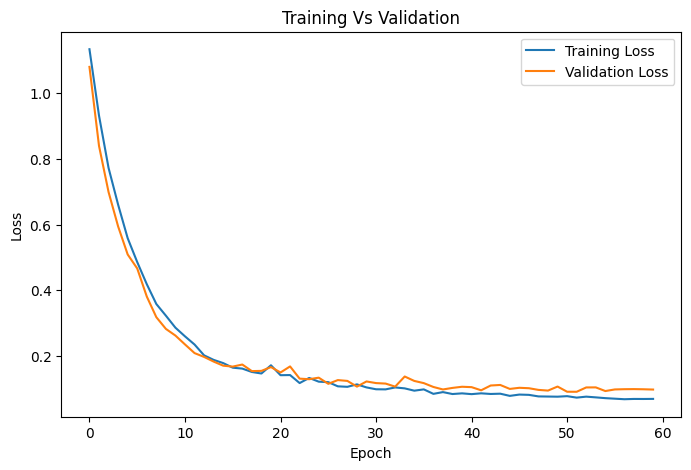

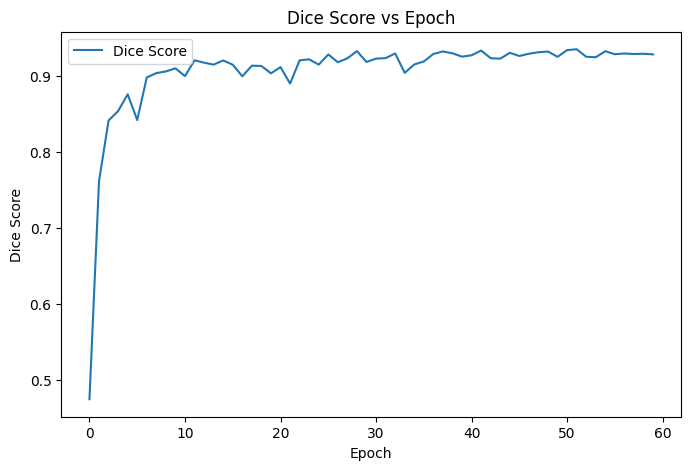

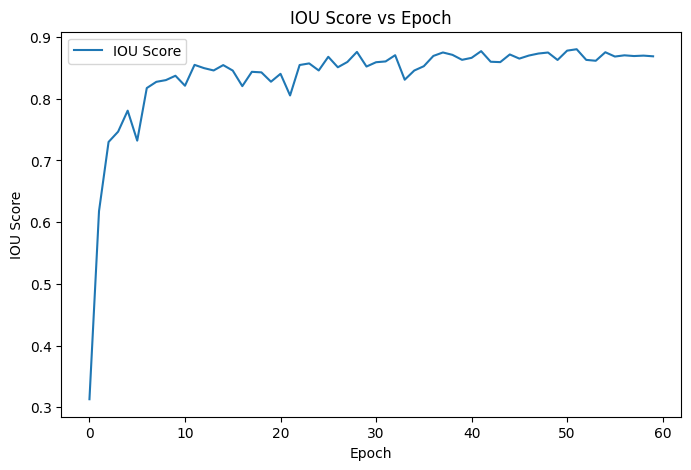

In [32]:
#Plotting The Curves

import matplotlib.pyplot as plt

plt.figure(figsize = (8,5))
plt.plot(train_losses4,label = "Training Loss")
plt.plot(val_losses4,label = "Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")
plt.title("Training Vs Validation")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(dice_scores4, label="Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice Score vs Epoch")
plt.legend()
plt.show()

plt.figure(figsize = (8,5))
plt.plot(iou_scores4,label = "IOU Score")
plt.xlabel("Epoch")
plt.ylabel("IOU Score")
plt.title("IOU Score vs Epoch")
plt.legend()
plt.show()